In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

main = pd.read_csv('../data/processed/ethiopia_fi_enriched_main.csv')
main['observation_date'] = pd.to_datetime(main['observation_date'], errors='coerce')

acc = main[(main['indicator_code']=='ACC_OWNERSHIP') & (main['gender']=='all') & (main['record_type']=='observation')].sort_values('observation_date')
mm = main[(main['indicator_code']=='ACC_MM_ACCOUNT') & (main['record_type']=='observation')].sort_values('observation_date')

print(acc[['observation_date','value_numeric']])
print()
print(mm[['observation_date','value_numeric']])

  observation_date  value_numeric
0       2014-12-31           22.0
1       2017-12-31           35.0
2       2021-12-31           46.0
5       2024-11-29           49.0

  observation_date  value_numeric
6       2021-12-31           4.70
7       2024-11-29           9.45


In [2]:
acc['year'] = acc['observation_date'].dt.year
X = sm.add_constant(acc['year'])
model = sm.OLS(acc['value_numeric'], X).fit()
print(model.summary())

future_years = pd.DataFrame({'year': [2025, 2026, 2027]})
Xf = sm.add_constant(future_years, has_constant='add')
pred = model.get_prediction(Xf)
pred_summary = pred.summary_frame(alpha=0.20)  # 80% CI, appropriate given n=4
pred_summary.index = [2025, 2026, 2027]
print("\nBaseline trend forecast (linear regression on all 4 points):")
print(pred_summary[['mean','mean_ci_lower','mean_ci_upper']].round(1))

                            OLS Regression Results                            
Dep. Variable:          value_numeric   R-squared:                       0.944
Model:                            OLS   Adj. R-squared:                  0.917
Method:                 Least Squares   F-statistic:                     33.98
Date:                Tue, 21 Jul 2026   Prob (F-statistic):             0.0282
Time:                        21:34:22   Log-Likelihood:                -9.3423
No. Observations:                   4   AIC:                             22.68
Df Residuals:                       2   BIC:                             21.46
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -5427.2241    937.622     -5.788      0.0

c:\Users\bamla\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 4 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [3]:
# Re-run the Task 3 event effect functions (paste from notebook 03 if not already in this kernel)
def event_effect_curve(dates, event_date, lag_months, magnitude_pp, ramp_months=18):
    onset = event_date + pd.DateOffset(months=lag_months)
    months_since_onset = (dates.year - onset.year) * 12 + (dates.month - onset.month)
    x = months_since_onset - ramp_months / 2
    realized_fraction = 1 / (1 + np.exp(-x / (ramp_months / 6)))
    realized_fraction = np.where(dates < onset, 0, realized_fraction)
    return magnitude_pp * realized_fraction

# Fayda mandate (EVT_0011) is the only event whose effect is still ramping into 2025-2027
mandate_event_date = pd.Timestamp('2025-01-08')
date_range = pd.date_range('2024-01-01', '2027-12-31', freq='MS')
mandate_effect = event_effect_curve(date_range, mandate_event_date, lag_months=12, magnitude_pp=8)
mandate_effect = pd.Series(mandate_effect, index=date_range)

last_actual = acc['value_numeric'].iloc[-1]  # 49.0, Nov 2024
last_actual_date = acc['observation_date'].iloc[-1]

# incremental effect realized between last actual observation and each forecast year-end
event_augmented = {}
for year in [2025, 2026, 2027]:
    year_end = pd.Timestamp(f'{year}-12-31')
    incremental = mandate_effect.asof(year_end) - mandate_effect.asof(last_actual_date)
    event_augmented[year] = last_actual + incremental

print("Event-augmented forecast (last actual + incremental Fayda-mandate effect):")
for y, v in event_augmented.items():
    print(y, ':', round(v, 1), '%')

Event-augmented forecast (last actual + incremental Fayda-mandate effect):
2025 : 49.0 %
2026 : 54.3 %
2027 : 56.9 %


In [4]:
scenarios_access = pd.DataFrame({
    'year': [2025, 2026, 2027],
    'optimistic': pred_summary['mean'].values,  # naive trend regression — upper bound case
    'base': [event_augmented[y] for y in [2025,2026,2027]],  # event-augmented, reflects recent deceleration
    'pessimistic': [49.0 + 1.0*(y-2024) for y in [2025,2026,2027]]  # continuation of 2021-24 rate (1.0pp/yr), no event boost
})
print(scenarios_access.round(1))

   year  optimistic  base  pessimistic
0  2025        54.2  49.0         50.0
1  2026        56.9  54.3         51.0
2  2027        59.7  56.9         52.0


In [5]:
# Only 2 data points (2021: 4.7%, 2024: 9.45%) -> use compound growth rate, not regression
years_elapsed = 2024 - 2021
cagr_observed = (9.45 / 4.7) ** (1/years_elapsed) - 1
print(f"Observed CAGR (2021-2024): {cagr_observed:.1%}")

def project(base_value, rate, n_years):
    return [base_value * (1+rate)**y for y in range(1, n_years+1)]

scenarios_usage = pd.DataFrame({
    'year': [2025, 2026, 2027],
    'optimistic': project(9.45, cagr_observed + 0.10, 3),   # boosted by M-Pesa/EthSwitch integration, EthioPay launch
    'base': project(9.45, cagr_observed, 3),                 # continuation of observed growth rate
    'pessimistic': project(9.45, cagr_observed - 0.12, 3),   # deceleration, mirroring the Access slowdown pattern
})
print(scenarios_usage.round(1))

Observed CAGR (2021-2024): 26.2%
   year  optimistic  base  pessimistic
0  2025        12.9  11.9         10.8
1  2026        17.5  15.1         12.3
2  2027        23.9  19.0         14.1


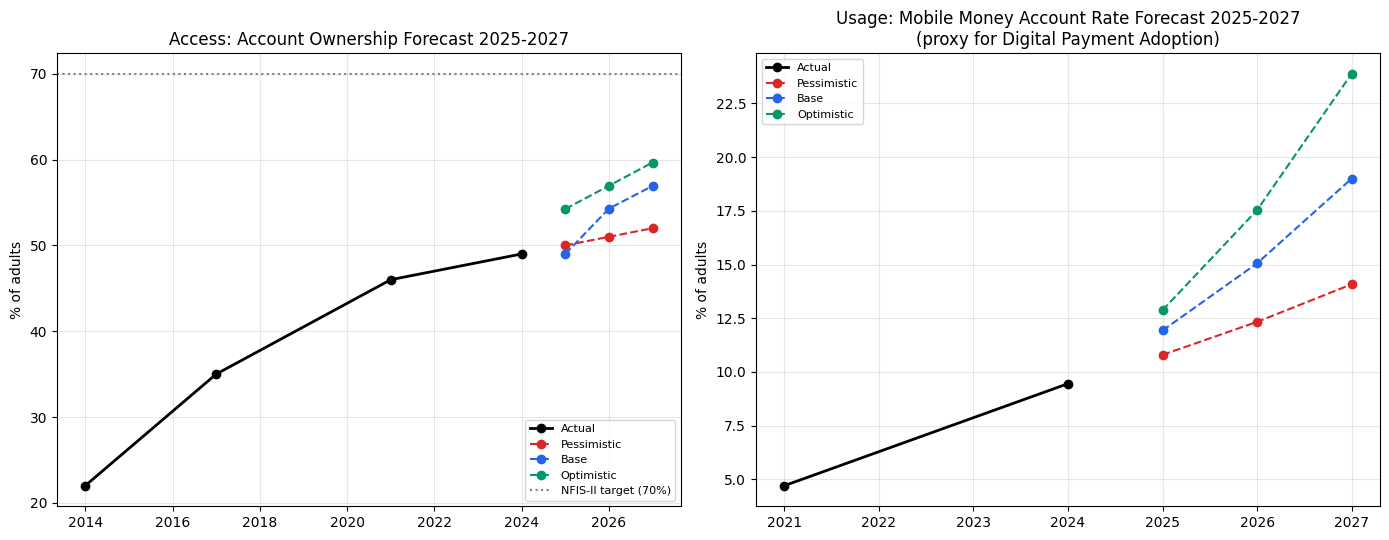

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].plot(acc['observation_date'].dt.year, acc['value_numeric'], marker='o', color='black', label='Actual', linewidth=2)
for col, color in zip(['pessimistic','base','optimistic'], ['#dc2626','#2563eb','#059669']):
    axes[0].plot(scenarios_access['year'], scenarios_access[col], marker='o', linestyle='--', color=color, label=col.capitalize())
axes[0].axhline(70, color='gray', linestyle=':', label='NFIS-II target (70%)')
axes[0].set_title("Access: Account Ownership Forecast 2025-2027")
axes[0].set_ylabel("% of adults"); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].plot(mm['observation_date'].dt.year, mm['value_numeric'], marker='o', color='black', label='Actual', linewidth=2)
for col, color in zip(['pessimistic','base','optimistic'], ['#dc2626','#2563eb','#059669']):
    axes[1].plot(scenarios_usage['year'], scenarios_usage[col], marker='o', linestyle='--', color=color, label=col.capitalize())
axes[1].set_title("Usage: Mobile Money Account Rate Forecast 2025-2027\n(proxy for Digital Payment Adoption)")
axes[1].set_ylabel("% of adults"); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/forecast_scenarios.png', dpi=150)
plt.show()

In [7]:
forecast_table = scenarios_access.merge(scenarios_usage, on='year', suffixes=('_access','_usage'))
forecast_table.columns = ['year','access_optimistic','access_base','access_pessimistic',
                           'usage_optimistic','usage_base','usage_pessimistic']
print(forecast_table.round(1).to_string(index=False))
forecast_table.to_csv('../reports/forecast_table.csv', index=False)

 year  access_optimistic  access_base  access_pessimistic  usage_optimistic  usage_base  usage_pessimistic
 2025               54.2         49.0                50.0              12.9        11.9               10.8
 2026               56.9         54.3                51.0              17.5        15.1               12.3
 2027               59.7         56.9                52.0              23.9        19.0               14.1


## Task 4: Forecast Interpretation

### Access (Account Ownership)
- **Base case**: 49% (2024) → 54.3% (2025) → 56.9% (2027), driven mainly by the Fayda mandatory-banking directive's expected effect on account opening via eKYC.
- **Optimistic**: the naive linear trend regression (59.7% by 2027) — this is a *ceiling*, not a likely path, since it ignores the 2021–24 deceleration confirmed in Task 2/3.
- **Pessimistic**: 52% by 2027, if the recent slow pace (1pp/yr) continues unaided by any event effect (e.g., mandate delayed or poorly enforced).
- **NFIS-II's 70% target by end-2025 will almost certainly be missed** under all three scenarios — even the optimistic path only reaches 59.7% by 2027.

### Usage (Mobile Money Account Rate — proxy for Digital Payment Adoption)
- **Base case**: 9.45% (2024) → 19.0% (2027), continuing the observed 26.2% CAGR.
- **Optimistic**: 23.9% by 2027, assuming additional lift from the M-Pesa/EthSwitch integration and EthioPay launch (both already in the impact_links but not yet reflected in observed data).
- **Pessimistic**: 14.1% by 2027, if growth decelerates the way Access growth did post-2021.
- Note this indicator is a *proxy*: the dataset has no direct time series for Findex's "made or received a digital payment" metric (reported at ~35% for 2024) — mobile money account ownership is the closest available Usage-pillar series with more than one data point.

### Largest-impact events for the forecast window
- **Fayda Mandatory Banking Directive (EVT_0011)**: single largest lever for Access in 2025-2027, given its Dec 2026 compliance deadline falls squarely in this window.
- **M-Pesa EthSwitch Integration & EthioPay launch**: both target Usage (P2P/active rate), reinforcing the Usage base/optimistic cases, but have no direct effect on Access in our impact_links.

### Key Uncertainties
- n=4 (Access) and n=2 (Usage) data points make any regression or CAGR estimate fragile — confidence intervals are wide and scenario spread is large by design.
- The next real Findex survey (~2027) is the only way to validate any of these forecasts against ground truth; until then, all figures should be treated as directional, not point predictions.
- The Fayda mandate's actual enforcement/compliance rate is unknown — its 8pp estimated effect (from India's comparable eKYC rollout) may not transfer well to Ethiopia's specific banking/documentation landscape.